# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The EV Adoption and Behavior Dataset](https://www.kaggle.com/datasets/itzzomkar/ev-adoption-behavior-and-range-anxiety/data)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('EV_Adoption_and_Range_Anxiety_Dataset.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,Buyer_ID,Age,Gender,Annual_Income_USD,City_Type,Daily_Commute_km,Number_of_Cars_Owned,Current_Car_Type,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Home_Charging_Possible,Environmental_Concern_Level,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,EV00001,56,Male,44906.0,Rural,18.1,1,Truck,1,0,Yes,4.0,Yes,Low,No
1,EV00002,36,Male,88754.0,Rural,5.0,1,SUV,2,3,Yes,1.0,Yes,Low,No
2,EV00003,42,Male,155958.0,Urban,32.2,2,Sedan,14,3,No,2.0,Yes,Medium,Yes
3,EV00004,31,Male,37059.0,Rural,89.9,1,Sedan,2,1,Yes,4.0,No,Low,No
4,EV00005,48,Female,48552.0,Rural,71.0,1,Sedan,2,0,Yes,3.0,Yes,Low,No


## last Five row

In [4]:
df.tail()

,Buyer_ID,Age,Gender,Annual_Income_USD,City_Type,Daily_Commute_km,Number_of_Cars_Owned,Current_Car_Type,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Home_Charging_Possible,Environmental_Concern_Level,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
9995,EV09996,50,Male,61279.0,Urban,71.4,1,Sedan,8,3,No,3.0,Yes,Medium,No
9996,EV09997,34,Male,108208.0,Urban,48.0,2,Hatchback,9,7,No,5.0,No,Low,No
9997,EV09998,60,Female,97743.0,Urban,9.0,2,Sedan,10,3,No,5.0,Yes,Low,No
9998,EV09999,31,Female,103628.0,Urban,81.8,2,SUV,10,10,Yes,1.0,Yes,Low,No
9999,EV10000,64,Other,59052.0,Suburban,24.0,2,Hatchback,1,9,Yes,5.0,Yes,Low,No


## Shape of our dataset

In [5]:
df.shape

(10000, 15)

## List out all columns

In [6]:
df.columns

Index(['Buyer_ID', 'Age', 'Gender', 'Annual_Income_USD', 'City_Type',
       'Daily_Commute_km', 'Number_of_Cars_Owned', 'Current_Car_Type',
       'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work',
       'Home_Charging_Possible', 'Environmental_Concern_Level',
       'Subsidy_Available', 'Range_Anxiety_Level', 'Will_Buy_EV'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Buyer_ID                        object
Age                              int64
Gender                          object
Annual_Income_USD              float64
City_Type                       object
Daily_Commute_km               float64
Number_of_Cars_Owned             int64
Current_Car_Type                object
Charging_Stations_Near_Home      int64
Charging_Stations_Near_Work      int64
Home_Charging_Possible          object
Environmental_Concern_Level    float64
Subsidy_Available               object
Range_Anxiety_Level             object
Will_Buy_EV                     object
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Buyer_ID                     10000 non-null  object 
 1   Age                          10000 non-null  int64  
 2   Gender                       10000 non-null  object 
 3   Annual_Income_USD            9822 non-null   float64
 4   City_Type                    10000 non-null  object 
 5   Daily_Commute_km             9819 non-null   float64
 6   Number_of_Cars_Owned         10000 non-null  int64  
 7   Current_Car_Type             10000 non-null  object 
 8   Charging_Stations_Near_Home  10000 non-null  int64  
 9   Charging_Stations_Near_Work  10000 non-null  int64  
 10  Home_Charging_Possible       10000 non-null  object 
 11  Environmental_Concern_Level  9816 non-null   float64
 12  Subsidy_Available            10000 non-null  object 
 13  Range_Anxiety_Lev

## Check Null Value

In [9]:
df.isnull().sum()

Buyer_ID                         0
Age                              0
Gender                           0
Annual_Income_USD              178
City_Type                        0
Daily_Commute_km               181
Number_of_Cars_Owned             0
Current_Car_Type                 0
Charging_Stations_Near_Home      0
Charging_Stations_Near_Work      0
Home_Charging_Possible           0
Environmental_Concern_Level    184
Subsidy_Available                0
Range_Anxiety_Level              0
Will_Buy_EV                      0
dtype: int64

## Drop Null Values

In [10]:
df.drop(columns=['Annual_Income_USD', 'Daily_Commute_km', 'Environmental_Concern_Level'], inplace=True)

## Check Dupicate Value

In [11]:
df.duplicated().sum()

np.int64(0)

## Summary

In [12]:
df.describe()

,Age,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,46.936200,1.859900,5.346900,7.458200
std,12.945968,0.855421,4.049074,5.259374
min,25.000000,1.000000,0.000000,0.000000
25%,36.000000,1.000000,2.000000,3.000000
50%,47.000000,2.000000,5.000000,6.000000
75%,58.000000,2.000000,8.000000,11.000000
max,69.000000,4.000000,14.000000,19.000000


# EDA

In [13]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

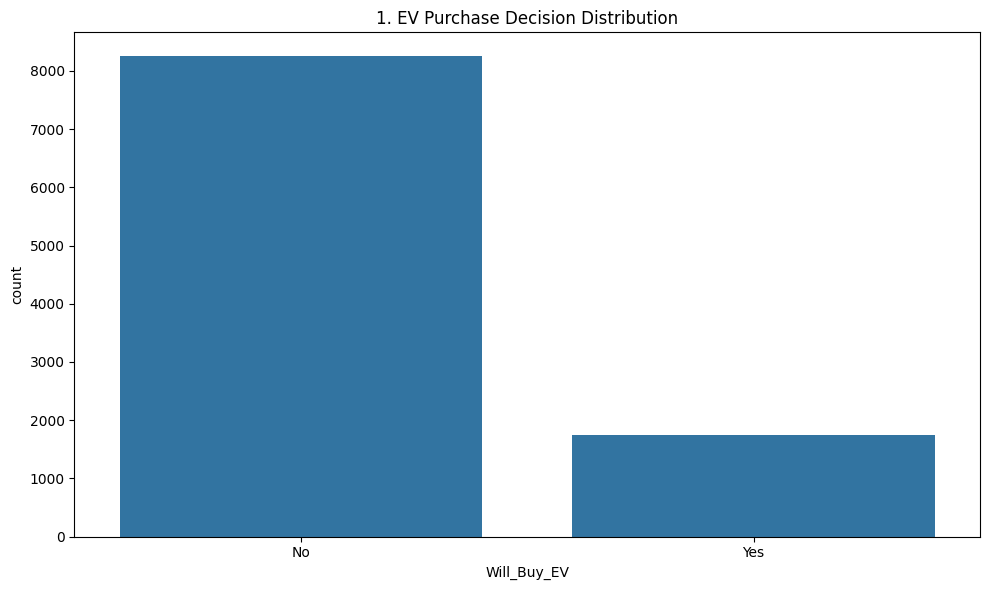

In [14]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Will_Buy_EV')
plt.title(f'{plot_no}. EV Purchase Decision Distribution')
show_fig()
plot_no += 1

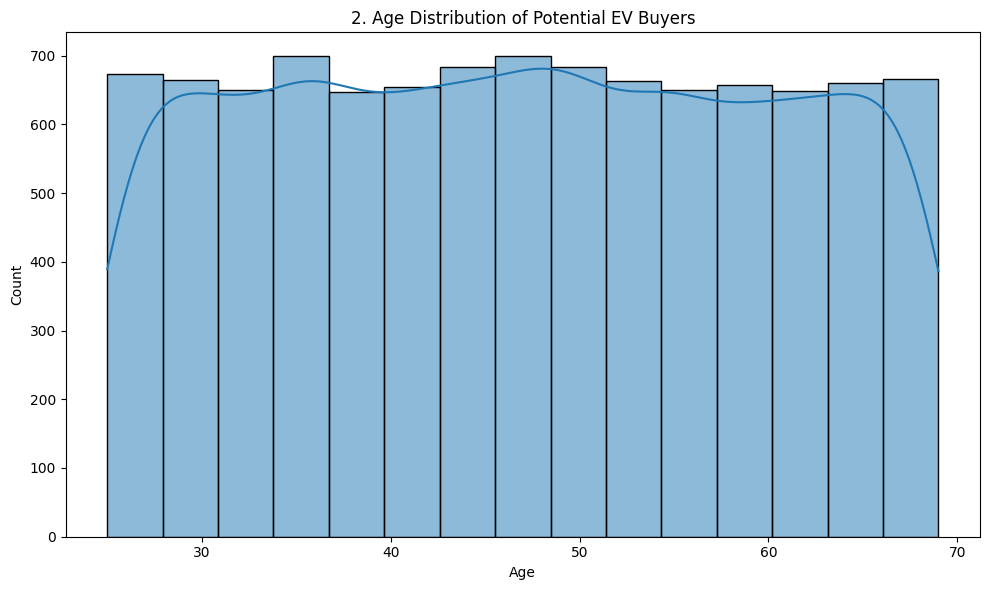

In [15]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Age', bins=15, kde=True)
plt.title(f'{plot_no}. Age Distribution of Potential EV Buyers')
show_fig()
plot_no += 1

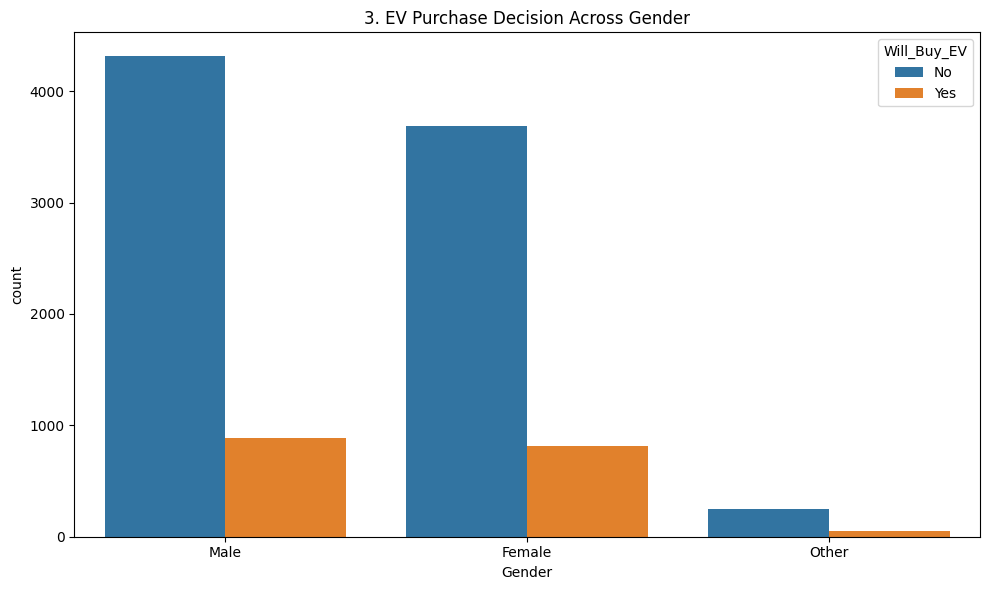

In [16]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Gender', hue='Will_Buy_EV')
plt.title(f'{plot_no}. EV Purchase Decision Across Gender')
show_fig()
plot_no += 1

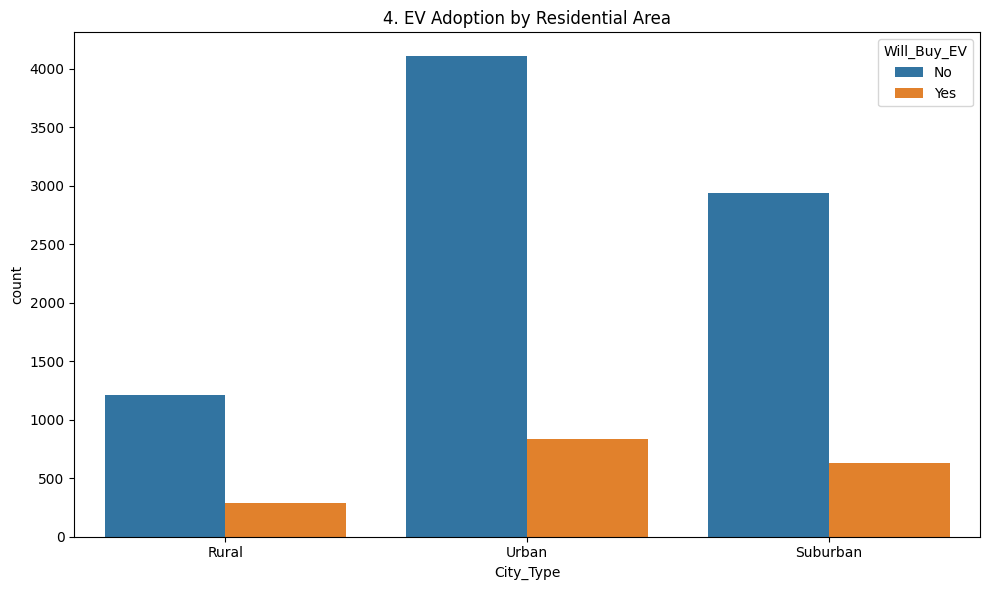

In [17]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='City_Type', hue='Will_Buy_EV')
plt.title(f'{plot_no}. EV Adoption by Residential Area')
show_fig()
plot_no += 1

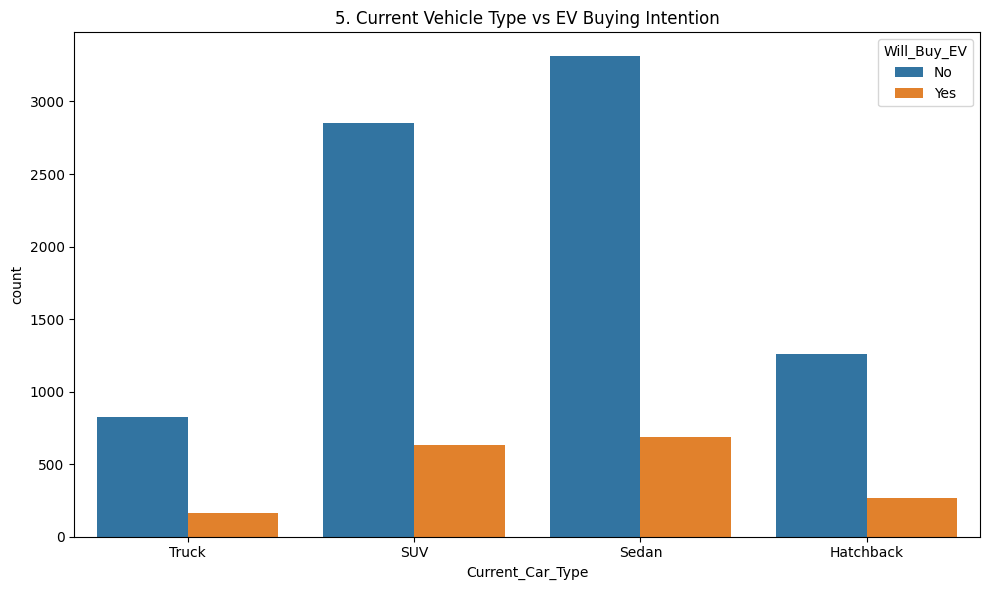

In [18]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Current_Car_Type', hue='Will_Buy_EV')
plt.title(f'{plot_no}. Current Vehicle Type vs EV Buying Intention')
show_fig()
plot_no += 1

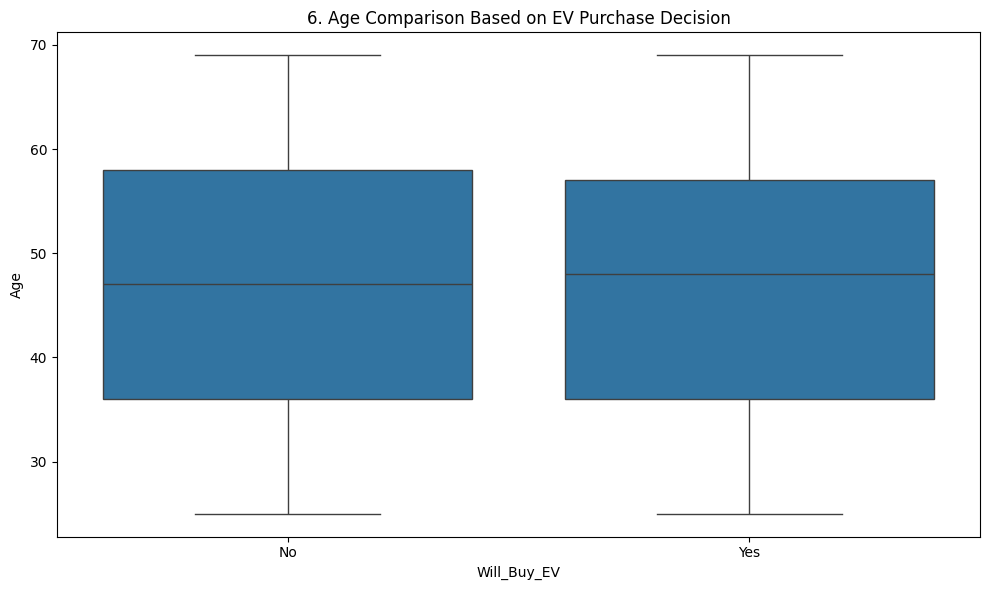

In [19]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Will_Buy_EV', y='Age')
plt.title(f'{plot_no}. Age Comparison Based on EV Purchase Decision')
show_fig()
plot_no += 1

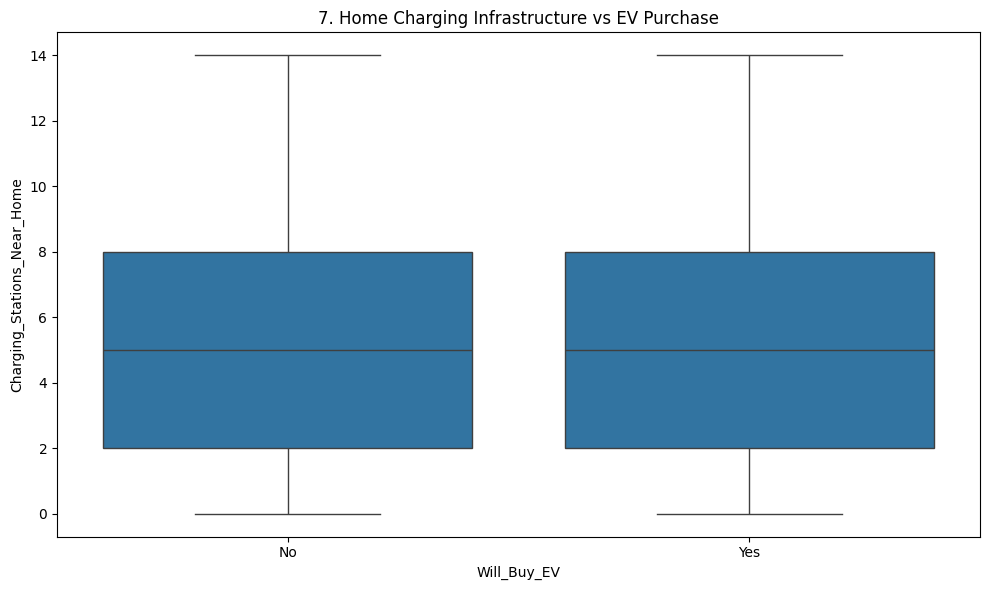

In [20]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Will_Buy_EV', y='Charging_Stations_Near_Home')
plt.title(f'{plot_no}. Home Charging Infrastructure vs EV Purchase')
show_fig()
plot_no += 1

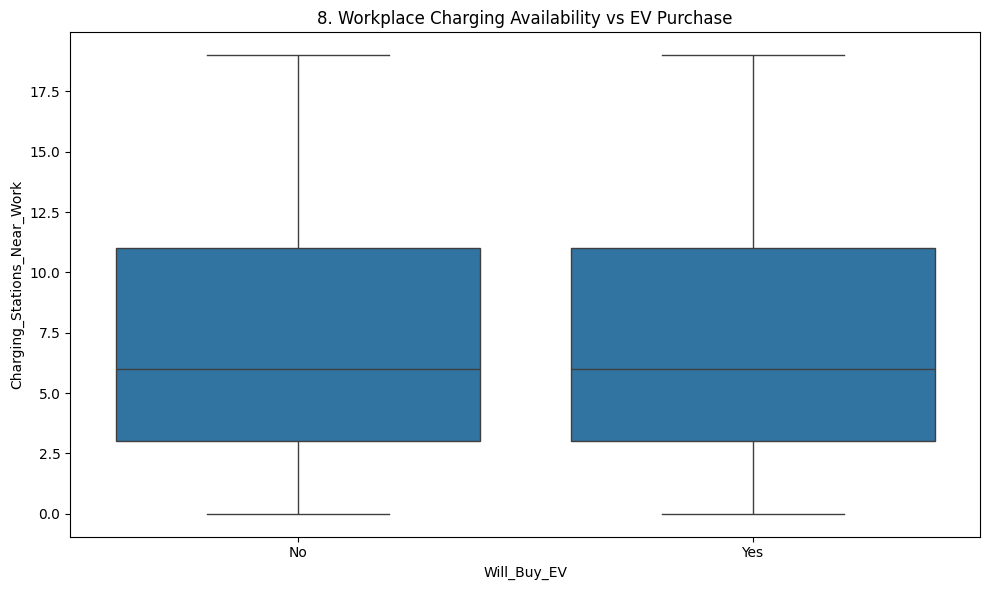

In [21]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Will_Buy_EV', y='Charging_Stations_Near_Work')
plt.title(f'{plot_no}. Workplace Charging Availability vs EV Purchase')
show_fig()
plot_no += 1

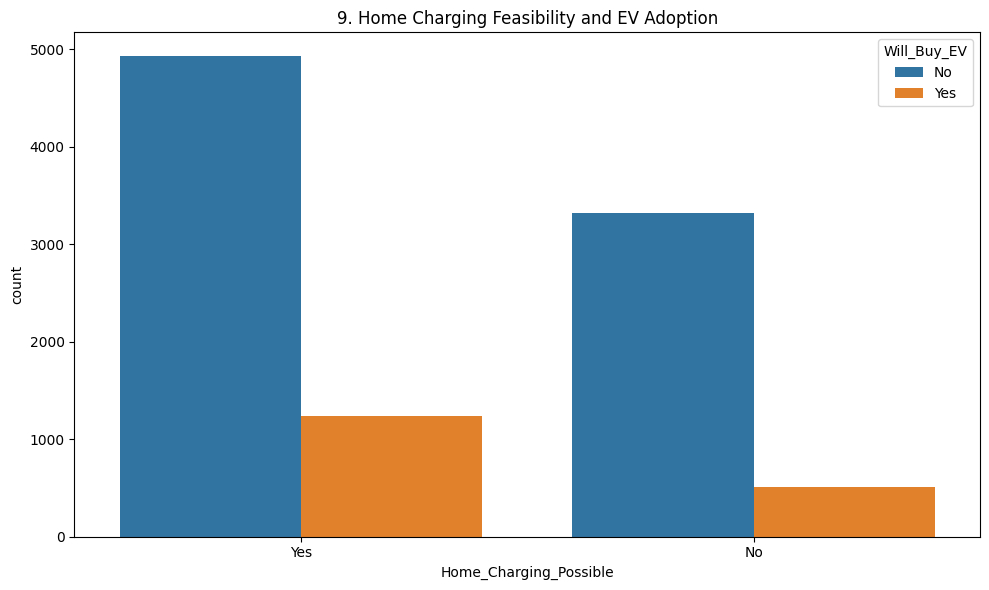

In [22]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Home_Charging_Possible', hue='Will_Buy_EV')
plt.title(f'{plot_no}. Home Charging Feasibility and EV Adoption')
show_fig()
plot_no += 1

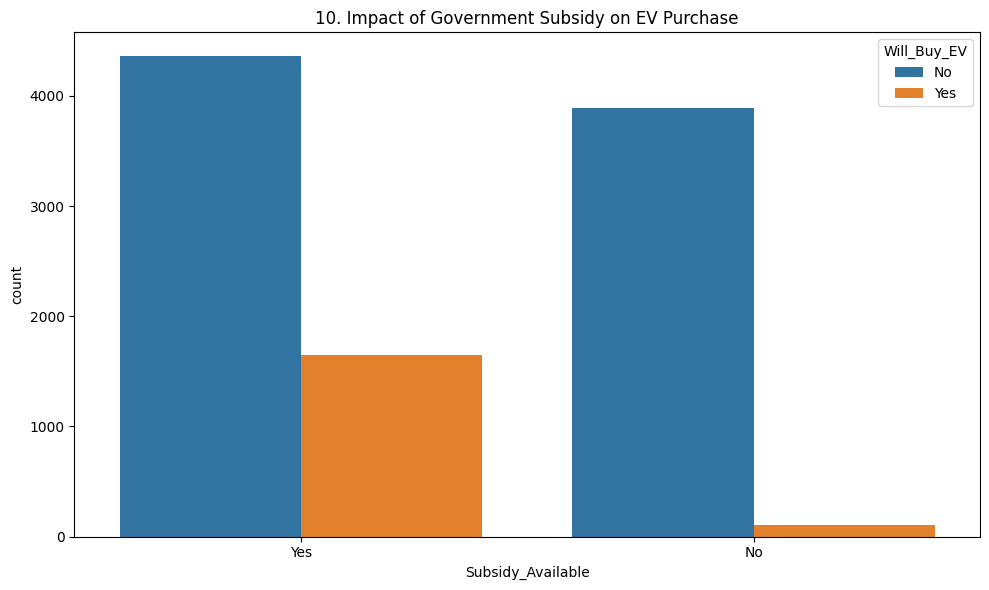

In [23]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Subsidy_Available', hue='Will_Buy_EV')
plt.title(f'{plot_no}. Impact of Government Subsidy on EV Purchase')
show_fig()
plot_no += 1

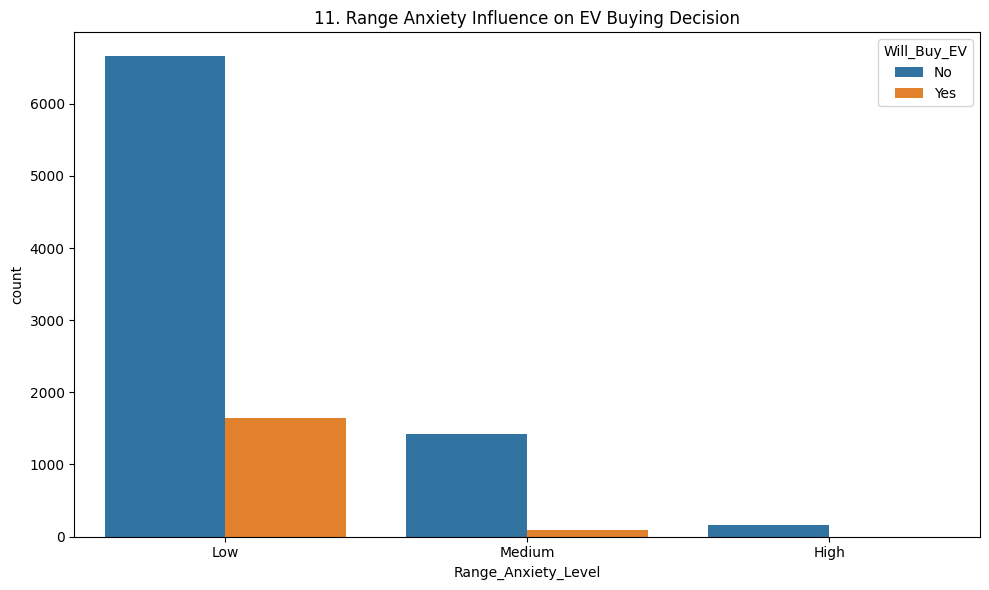

In [24]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Range_Anxiety_Level', hue='Will_Buy_EV')
plt.title(f'{plot_no}. Range Anxiety Influence on EV Buying Decision')
show_fig()
plot_no += 1

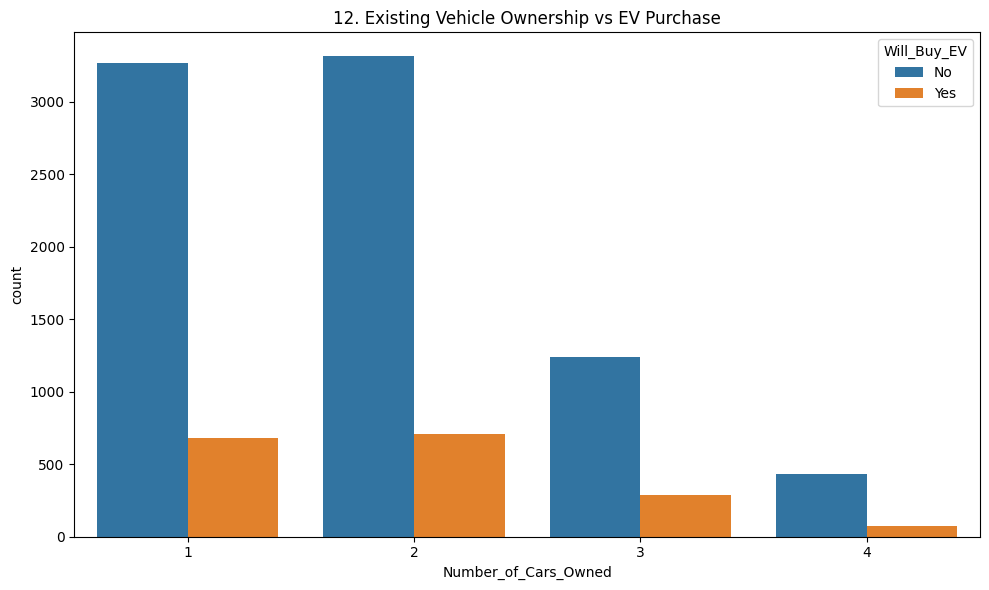

In [25]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Number_of_Cars_Owned', hue='Will_Buy_EV')
plt.title(f'{plot_no}. Existing Vehicle Ownership vs EV Purchase')
show_fig()
plot_no += 1

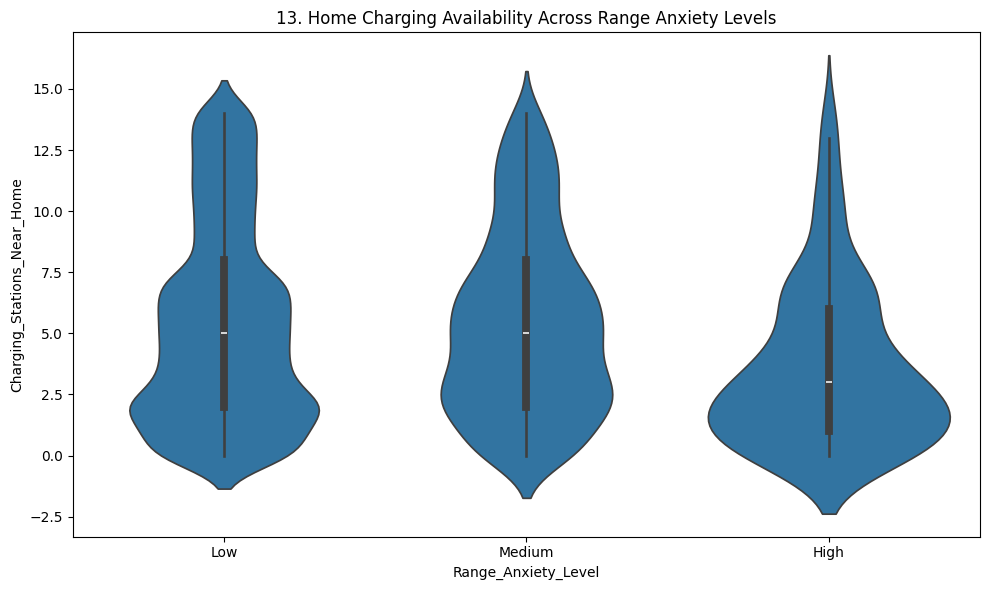

In [26]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='Range_Anxiety_Level', y='Charging_Stations_Near_Home')
plt.title(f'{plot_no}. Home Charging Availability Across Range Anxiety Levels')
show_fig()
plot_no += 1

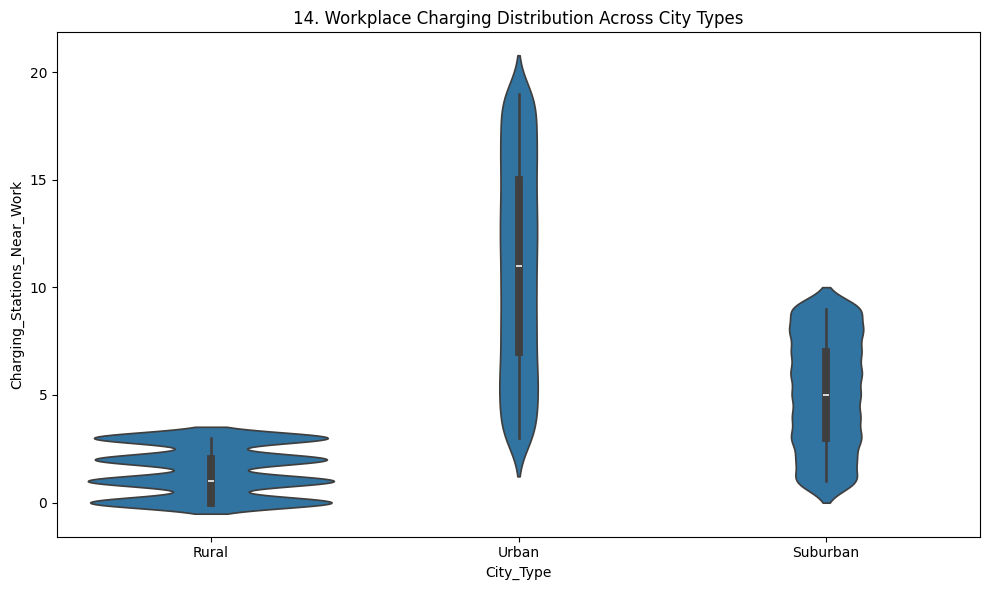

In [27]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='City_Type', y='Charging_Stations_Near_Work')
plt.title(f'{plot_no}. Workplace Charging Distribution Across City Types')
show_fig()
plot_no += 1

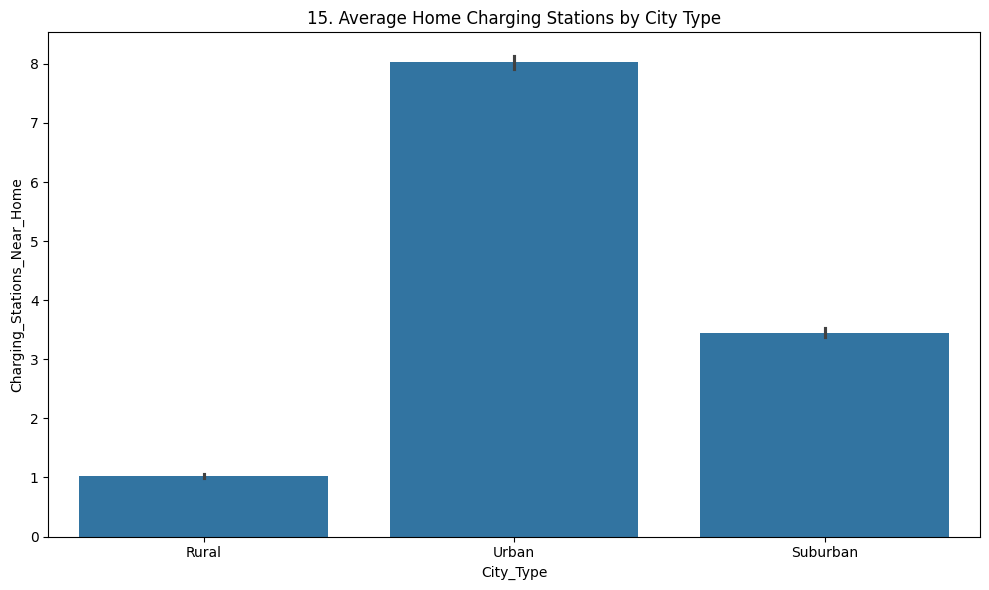

In [28]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='City_Type', y='Charging_Stations_Near_Home', estimator='mean')
plt.title(f'{plot_no}. Average Home Charging Stations by City Type')
show_fig()
plot_no += 1

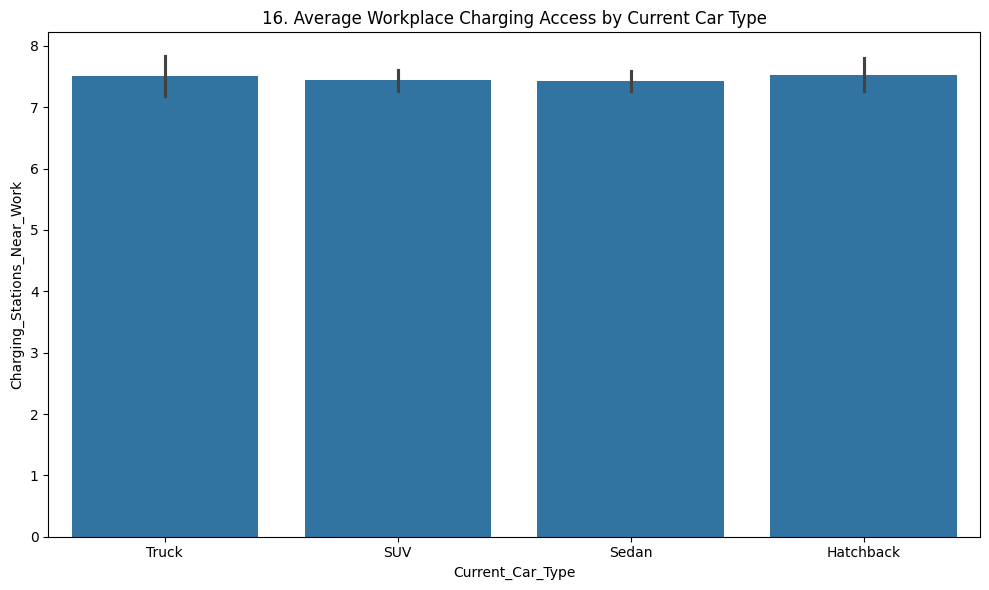

In [29]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Current_Car_Type', y='Charging_Stations_Near_Work', estimator='mean')
plt.title(f'{plot_no}. Average Workplace Charging Access by Current Car Type')
show_fig()
plot_no += 1

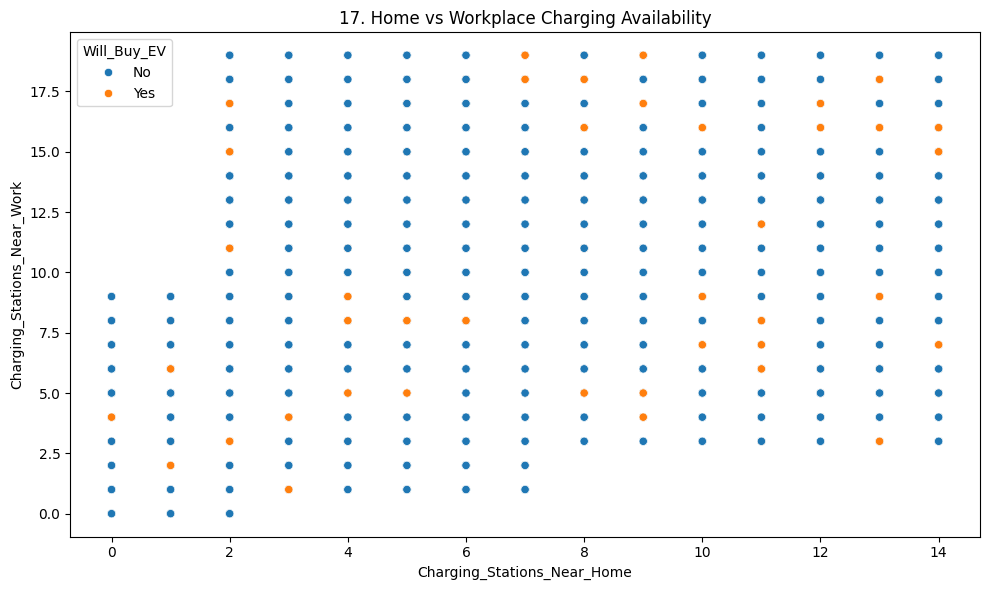

In [30]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='Charging_Stations_Near_Home',
    y='Charging_Stations_Near_Work',
    hue='Will_Buy_EV'
)
plt.title(f'{plot_no}. Home vs Workplace Charging Availability')
show_fig()
plot_no += 1

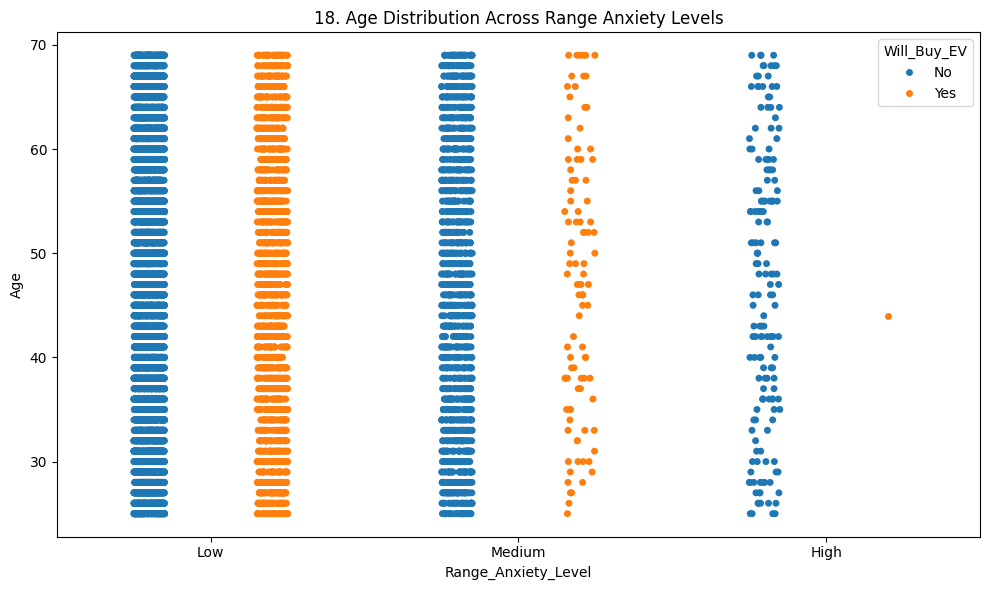

In [31]:
fig = plt.figure(figsize=(10,6))
sns.stripplot(
    data=df,
    x='Range_Anxiety_Level',
    y='Age',
    hue='Will_Buy_EV',
    dodge=True
)
plt.title(f'{plot_no}. Age Distribution Across Range Anxiety Levels')
show_fig()
plot_no += 1

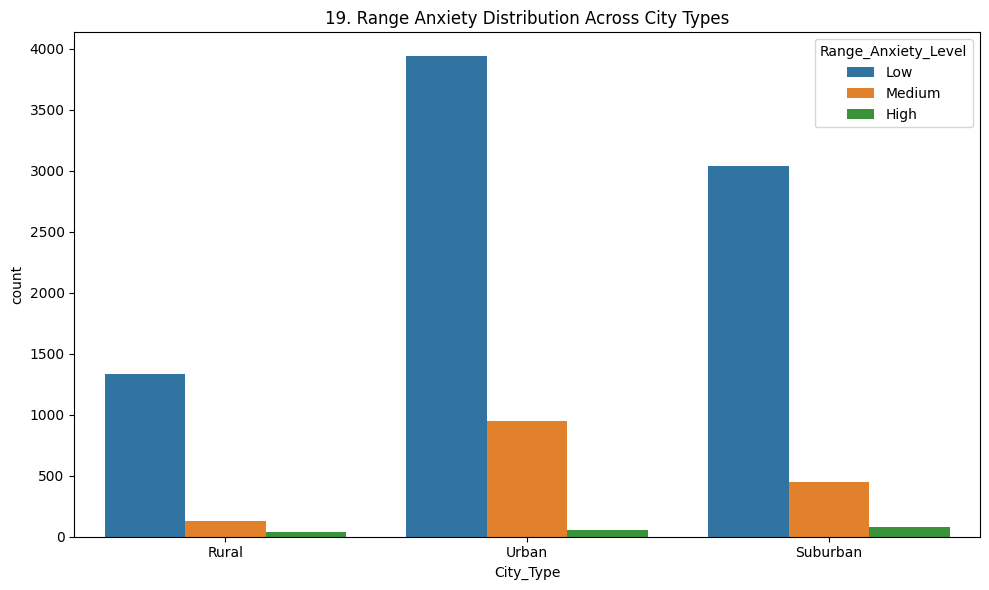

In [32]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='City_Type', hue='Range_Anxiety_Level')
plt.title(f'{plot_no}. Range Anxiety Distribution Across City Types')
show_fig()
plot_no += 1

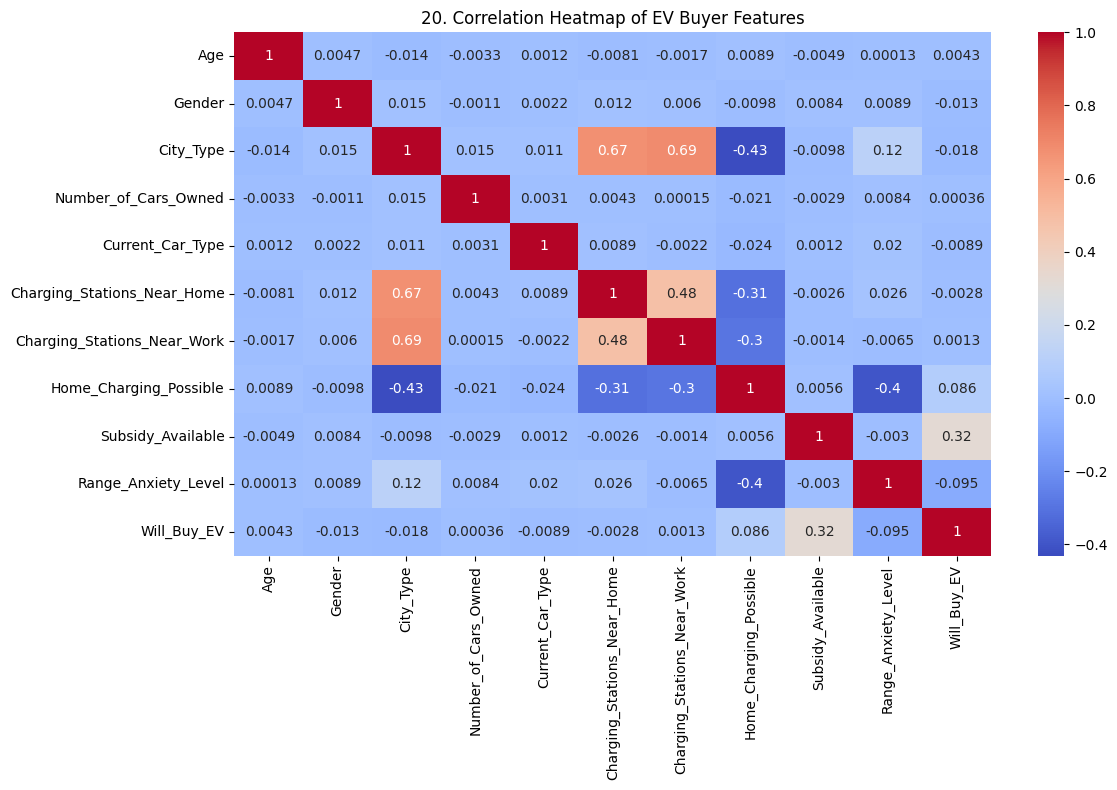

In [33]:
corr = df.drop(columns=['Buyer_ID']).apply(lambda x: x.astype('category').cat.codes if x.dtype == 'object' else x).corr()

fig = plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of EV Buyer Features')
show_fig()
plot_no += 1

# Model Training

## Create a copy of the dataset

In [34]:
data = df.copy()

## Set features and target

In [35]:
X = data.drop(columns=['Buyer_ID', 'Home_Charging_Possible'])
y = data['Home_Charging_Possible']

## Encode target column

In [36]:
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

## Encode categorical feature columns

In [37]:
categorical_cols = X.select_dtypes(include='object').columns

for col in categorical_cols:
    encoder = LabelEncoder()
    X[col] = encoder.fit_transform(X[col])

## Split the dataset

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## Scale numerical features

In [39]:
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

## Train Gradient Boosting model

In [40]:
model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    min_samples_split=4,
    min_samples_leaf=2,
    subsample=0.9,
    random_state=42
)

model.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.05
,n_estimators,300
,subsample,0.9
,criterion,'friedman_mse'
,min_samples_split,4
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_depth,5
,min_impurity_decrease,0.0
,init,None


## Predict on test data

In [41]:
y_pred = model.predict(X_test)

## Print model accuracy

In [42]:
accuracy = accuracy_score(y_test, y_pred)
accuracy = round(accuracy * 100)
print(f'Accuracy Score : {accuracy}%')

Accuracy Score : 77%


## Print classification report

In [43]:
print("\nClassification Report\n")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=target_encoder.classes_
    )
)


Classification Report

              precision    recall  f1-score   support

          No       0.72      0.68      0.70       767
         Yes       0.81      0.83      0.82      1233

    accuracy                           0.77      2000
   macro avg       0.76      0.76      0.76      2000
weighted avg       0.77      0.77      0.77      2000



## Plot Actual vs Predicted Confusion Matrix

<Figure size 700x600 with 0 Axes>

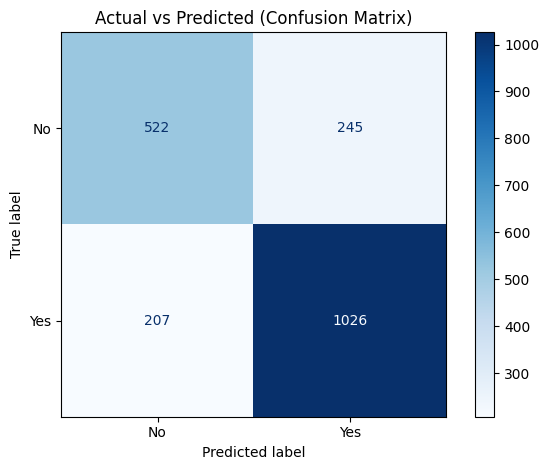

In [44]:
fig = plt.figure(figsize=(7,6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=target_encoder.classes_,
    cmap='Blues'
)

plt.title('Actual vs Predicted (Confusion Matrix)')
plt.tight_layout()
plt.show()